# 准备数据

In [1]:
# 加载模块
import polars as pl

from vnpy.trader.constant import Interval

from vnpy.alpha import AlphaLab

In [2]:
# 创建数据中心
lab: AlphaLab = AlphaLab("./lab/csi300")

In [3]:
# 设置任务参数
name = "double_ensemble"
index_symbol: str = "000300.SSE"
start: str = "2008-01-01"
end: str = "2024-12-31"
interval: Interval = Interval.DAILY
extended_days: int = 100

In [4]:
# 加载所有成分股代码
component_symbols: list[str] = lab.load_component_symbols(index_symbol, start, end)

# 特征计算

In [5]:
# 加载模块
from datetime import datetime
from functools import partial

from vnpy.trader.constant import Interval

from vnpy.alpha.dataset import (
    AlphaDataset,
    process_drop_na,
    process_robust_zscore_norm,
    process_fill_na,
    process_cs_rank_norm,
    to_datetime
)
from vnpy.alpha.dataset.datasets.alpha_158 import Alpha158


In [6]:
# 加载成分股数据
df: pl.DataFrame = lab.load_bar_df(component_symbols, interval, start, end, extended_days)

In [7]:
# 设置数据时间段
train_period: tuple[str, str] = ("2008-01-01", "2014-12-31")
valid_period: tuple[str, str] = ("2015-01-01", "2016-12-31")
test_period: tuple[str, str] = ("2017-01-01", "2020-8-31")

In [8]:
# 创建数据集对象
dataset: AlphaDataset = Alpha158(
    df,
    train_period=train_period,
    valid_period=valid_period,
    test_period=test_period,
)

In [9]:
# 添加数据预处理器
fit_start_time: datetime = to_datetime(train_period[0])
fit_end_time: datetime = to_datetime(train_period[1])

dataset.add_processor("infer", partial(process_robust_zscore_norm, fit_start_time=fit_start_time, fit_end_time=fit_end_time))
dataset.add_processor("infer", partial(process_fill_na, fill_value=0, fill_label=False))

dataset.add_processor("learn", partial(process_drop_na, names=["label"]))
dataset.add_processor("learn", partial(process_cs_rank_norm, names=["label"]))

In [10]:
# 收集指数成分过滤器
filters: dict[str, list[str]] = lab.load_component_filters(index_symbol, start, end)

In [11]:
# 准备特征和标签数据
dataset.prepare_data(filters)

dataset.process_data()

2026-05-11 17:43:08 开始计算表达式因子特征


100%|████████████████████████████████████████████████████████████████████████████████| 159/159 [30:11<00:00, 11.39s/it]


2026-05-11 18:13:22 开始合并结果数据因子特征


0it [00:00, ?it/s]


2026-05-11 18:13:24 开始筛选成分股数据


100%|███████████████████████████████████████████████████████████████████████████████| 824/824 [00:06<00:00, 135.93it/s]


In [12]:
# 保存到文件缓存
lab.save_dataset(name, dataset)

# 模型训练

In [13]:
# 加载模块
import numpy as np

from vnpy.alpha.dataset import Segment
from vnpy.alpha.model import AlphaModel

from doubleensemble_model import DoubleensembleModel

In [14]:
# 加载数据集
dataset: AlphaDataset = lab.load_dataset(name)

In [15]:
#导入超参数优化库optuna
import optuna
from optuna import Trial

# # 定义优化目标函数

FIXED_PARAMS = {
    "base_model": "gbm",
    "loss": "mse",
    "sample_ratios":  [1, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1, 0],
    "epochs": 28,
    "early_stopping_rounds": 3,
}

# %% 
def objective(trial: Trial):
    tuning_params = {
        "num_models": trial.suggest_int("num_models", 3, 8),  # 优化模型数量，范围1到5
        "enable_sr": trial.suggest_categorical("enable_sr", [True, False]),  # 是否启用 SR
        "enable_fs": trial.suggest_categorical("enable_fs", [True, False]),  # 是否启用 FS
        "alpha1": trial.suggest_float("alpha1", 0.1, 2.0),  # 优化 alpha1 参数，范围0.1到2.0
        "alpha2": trial.suggest_float("alpha2", 0.1, 2.0),  # 优化 alpha2 参数，范围0.1到2.0
        "bins_sr": trial.suggest_int("bins_sr", 5, 10),  # 优化 bins_sr，范围5到20
        "bins_fs": trial.suggest_int("bins_fs", 5, 10),  # 优化 bins_fs，范围5到20
        "decay": trial.suggest_float("decay", 0.1, 1.0),  # 优化 decay 参数，范围0.1到1.0
    }
    
    params = {**FIXED_PARAMS, **tuning_params}
    
    # 加载数据集并训练模型
    model = DoubleensembleModel(**params)
    model.fit(dataset)
    
    
    return model.valid_loss

D:\veighna_studio\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [16]:
# 执行超参数优化
study = optuna.create_study(direction='minimize')  # 最小化目标（比如损失）

study.optimize(objective, n_jobs=1, n_trials=5, show_progress_bar=True)  # n_trials是试验的次数

[I 2026-05-11 18:15:26,568] A new study created in memory with name: no-name-80d4ff28-4704-45c7-bafd-7dd9f9ff0632
  0%|                                                                                            | 0/5 [00:00<?, ?it/s]

Training until validation scores don't improve for 3 rounds
[20]	train's l2: 0.976785	valid's l2: 0.989187
Did not meet early stopping. Best iteration is:
[27]	train's l2: 0.973078	valid's l2: 0.988886
Training until validation scores don't improve for 3 rounds
[20]	train's l2: 0.976785	valid's l2: 0.989187
Did not meet early stopping. Best iteration is:
[27]	train's l2: 0.973078	valid's l2: 0.988886
Training until validation scores don't improve for 3 rounds
[20]	train's l2: 0.976785	valid's l2: 0.989187
Did not meet early stopping. Best iteration is:
[27]	train's l2: 0.973078	valid's l2: 0.988886


Best trial: 0. Best value: 0.988886:  20%|█████████▍                                     | 1/5 [00:24<01:38, 24.70s/it]

[I 2026-05-11 18:15:51,282] Trial 0 finished with value: 0.9888858022795685 and parameters: {'num_models': 3, 'enable_sr': False, 'enable_fs': False, 'alpha1': 1.1143957557616235, 'alpha2': 1.6115000459471764, 'bins_sr': 7, 'bins_fs': 8, 'decay': 0.4345551093189647}. Best is trial 0 with value: 0.9888858022795685.
Training until validation scores don't improve for 3 rounds
[20]	train's l2: 0.976785	valid's l2: 0.989187
Did not meet early stopping. Best iteration is:
[27]	train's l2: 0.973078	valid's l2: 0.988886


D:\GitHub\vnpy_alphastrategy\csi300\doubleensemble_model.py:399: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  g["g_value"].replace(np.nan, 0, inplace=True)


...

Training until validation scores don't improve for 3 rounds
Early stopping, best iteration is:
[3]	train's l2: 1.10351	valid's l2: 0.991073


D:\GitHub\vnpy_alphastrategy\csi300\doubleensemble_model.py:328: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  h_avg: pd.Series = h.groupby("bins")["h_value"].mean()


Training until validation scores don't improve for 3 rounds
Early stopping, best iteration is:
[2]	train's l2: 1.08583	valid's l2: 0.991608


Best trial: 0. Best value: 0.988886: 100%|██████████████████████████████████████████████| 5/5 [54:59<00:00, 659.94s/it]

[I 2026-05-11 19:10:26,303] Trial 4 finished with value: 0.9916079234610501 and parameters: {'num_models': 3, 'enable_sr': True, 'enable_fs': False, 'alpha1': 0.8399491509258689, 'alpha2': 1.4065561013074719, 'bins_sr': 7, 'bins_fs': 9, 'decay': 0.4205593972848837}. Best is trial 0 with value: 0.9888858022795685.


In [17]:
# 输出最优超参数
trials_df = study.trials_dataframe()

study.best_params

{'num_models': 3,
 'enable_sr': False,
 'enable_fs': False,
 'alpha1': 1.1143957557616235,
 'alpha2': 1.6115000459471764,
 'bins_sr': 7,
 'bins_fs': 8,
 'decay': 0.4345551093189647}

In [18]:
best_params = {**FIXED_PARAMS, **study.best_params}

In [19]:
# 使用最优超参来训练模型
model: AlphaModel = DoubleensembleModel(**best_params)
model.fit(dataset)

Training until validation scores don't improve for 3 rounds
[20]	train's l2: 0.976785	valid's l2: 0.989187
Did not meet early stopping. Best iteration is:
[27]	train's l2: 0.973078	valid's l2: 0.988886
Training until validation scores don't improve for 3 rounds
[20]	train's l2: 0.976785	valid's l2: 0.989187
Did not meet early stopping. Best iteration is:
[27]	train's l2: 0.973078	valid's l2: 0.988886
Training until validation scores don't improve for 3 rounds
[20]	train's l2: 0.976785	valid's l2: 0.989187
Did not meet early stopping. Best iteration is:
[27]	train's l2: 0.973078	valid's l2: 0.988886


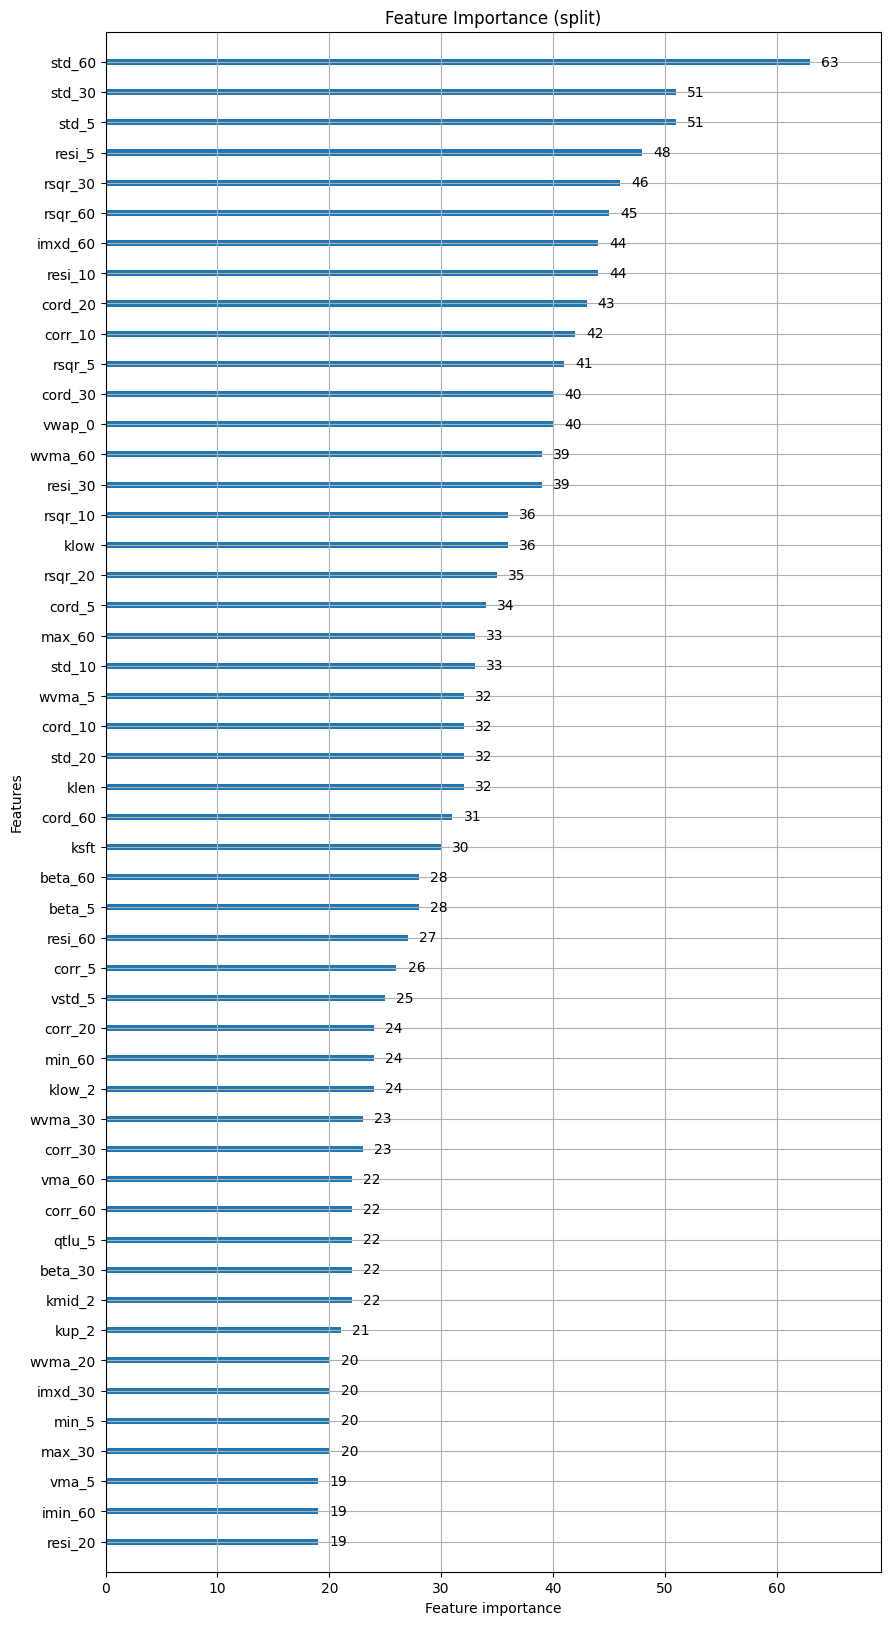

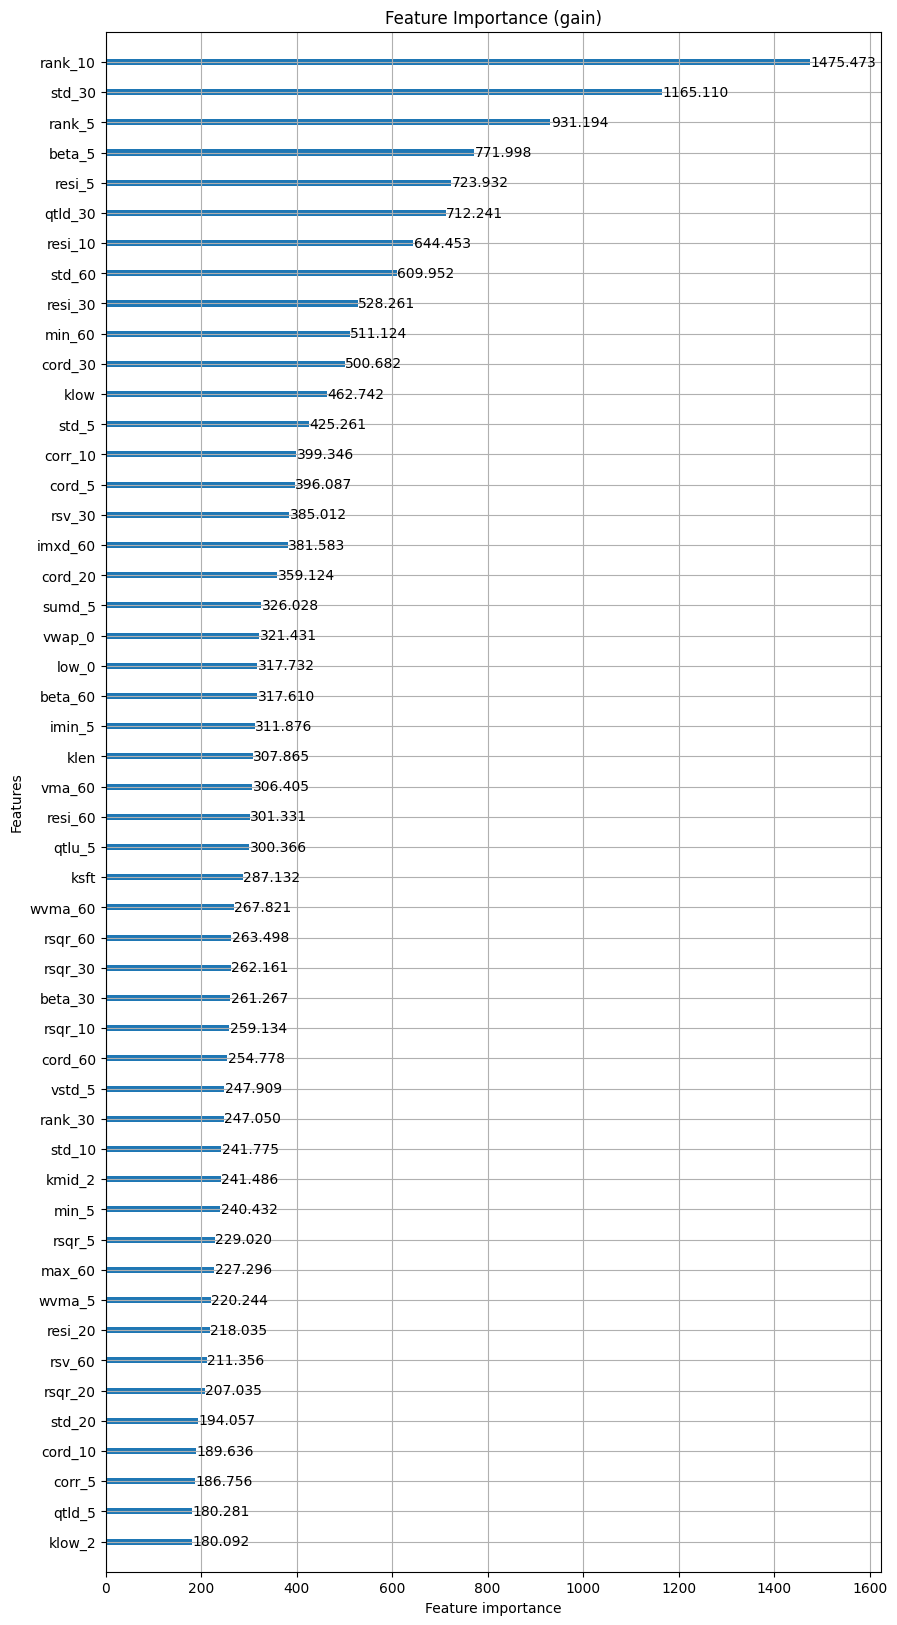

In [20]:
# 查看模型细节
model.detail()

In [21]:
# 用模型在测试集上预测
pre: np.ndarray = model.predict(dataset, Segment.TEST)

# 加载测试集数据
df_t: pl.DataFrame = dataset.fetch_infer(Segment.TEST)

# 合并预测信号列
df_t = df_t.with_columns(pl.Series(pre).alias("signal"))

# 提取信号数据
signal: pl.DataFrame = df_t["datetime", "vt_symbol", "signal"]

D:\veighna_studio\Lib\site-packages\alphalens\utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
D:\veighna_studio\Lib\site-packages\alphalens\utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = prices.pct_change(period)
D:\veighna_studio\Lib\site-packages\alphalens\utils.py:308: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  retu

Dropped 1.1% entries from factor data: 1.1% in forward returns computation and 0.0% in binning phase (set max_loss=0 to see potentially suppressed Exceptions).
max_loss is 100.0%, not exceeded: OK!
Quantiles Statistics


,min,max,mean,std,count,count %
factor_quantile,,,,,,
1,-0.387114,0.014023,-0.140943,0.054717,26460,10.000000
2,-0.257470,0.057359,-0.071195,0.037105,26460,10.000000
3,-0.223912,0.082169,-0.036475,0.035545,26460,10.000000
4,-0.193480,0.110701,-0.010479,0.034556,26461,10.000378
5,-0.171001,0.132326,0.011468,0.033530,26460,10.000000
6,-0.150501,0.154815,0.031674,0.033117,26461,10.000378
7,-0.122874,0.178528,0.052253,0.033173,26458,9.999244
8,-0.096623,0.210494,0.075088,0.033652,26460,10.000000
9,-0.059034,0.238547,0.104109,0.034975,26460,10.000000


Returns Analysis


,1D,5D,10D
Ann. alpha,0.409,0.223,0.120
beta,-0.012,-0.020,-0.041
Mean Period Wise Return Top Quantile (bps),22.280,12.848,7.934
Mean Period Wise Return Bottom Quantile (bps),-18.075,-9.996,-4.695
Mean Period Wise Spread (bps),40.356,22.868,12.634


<Figure size 640x480 with 0 Axes>

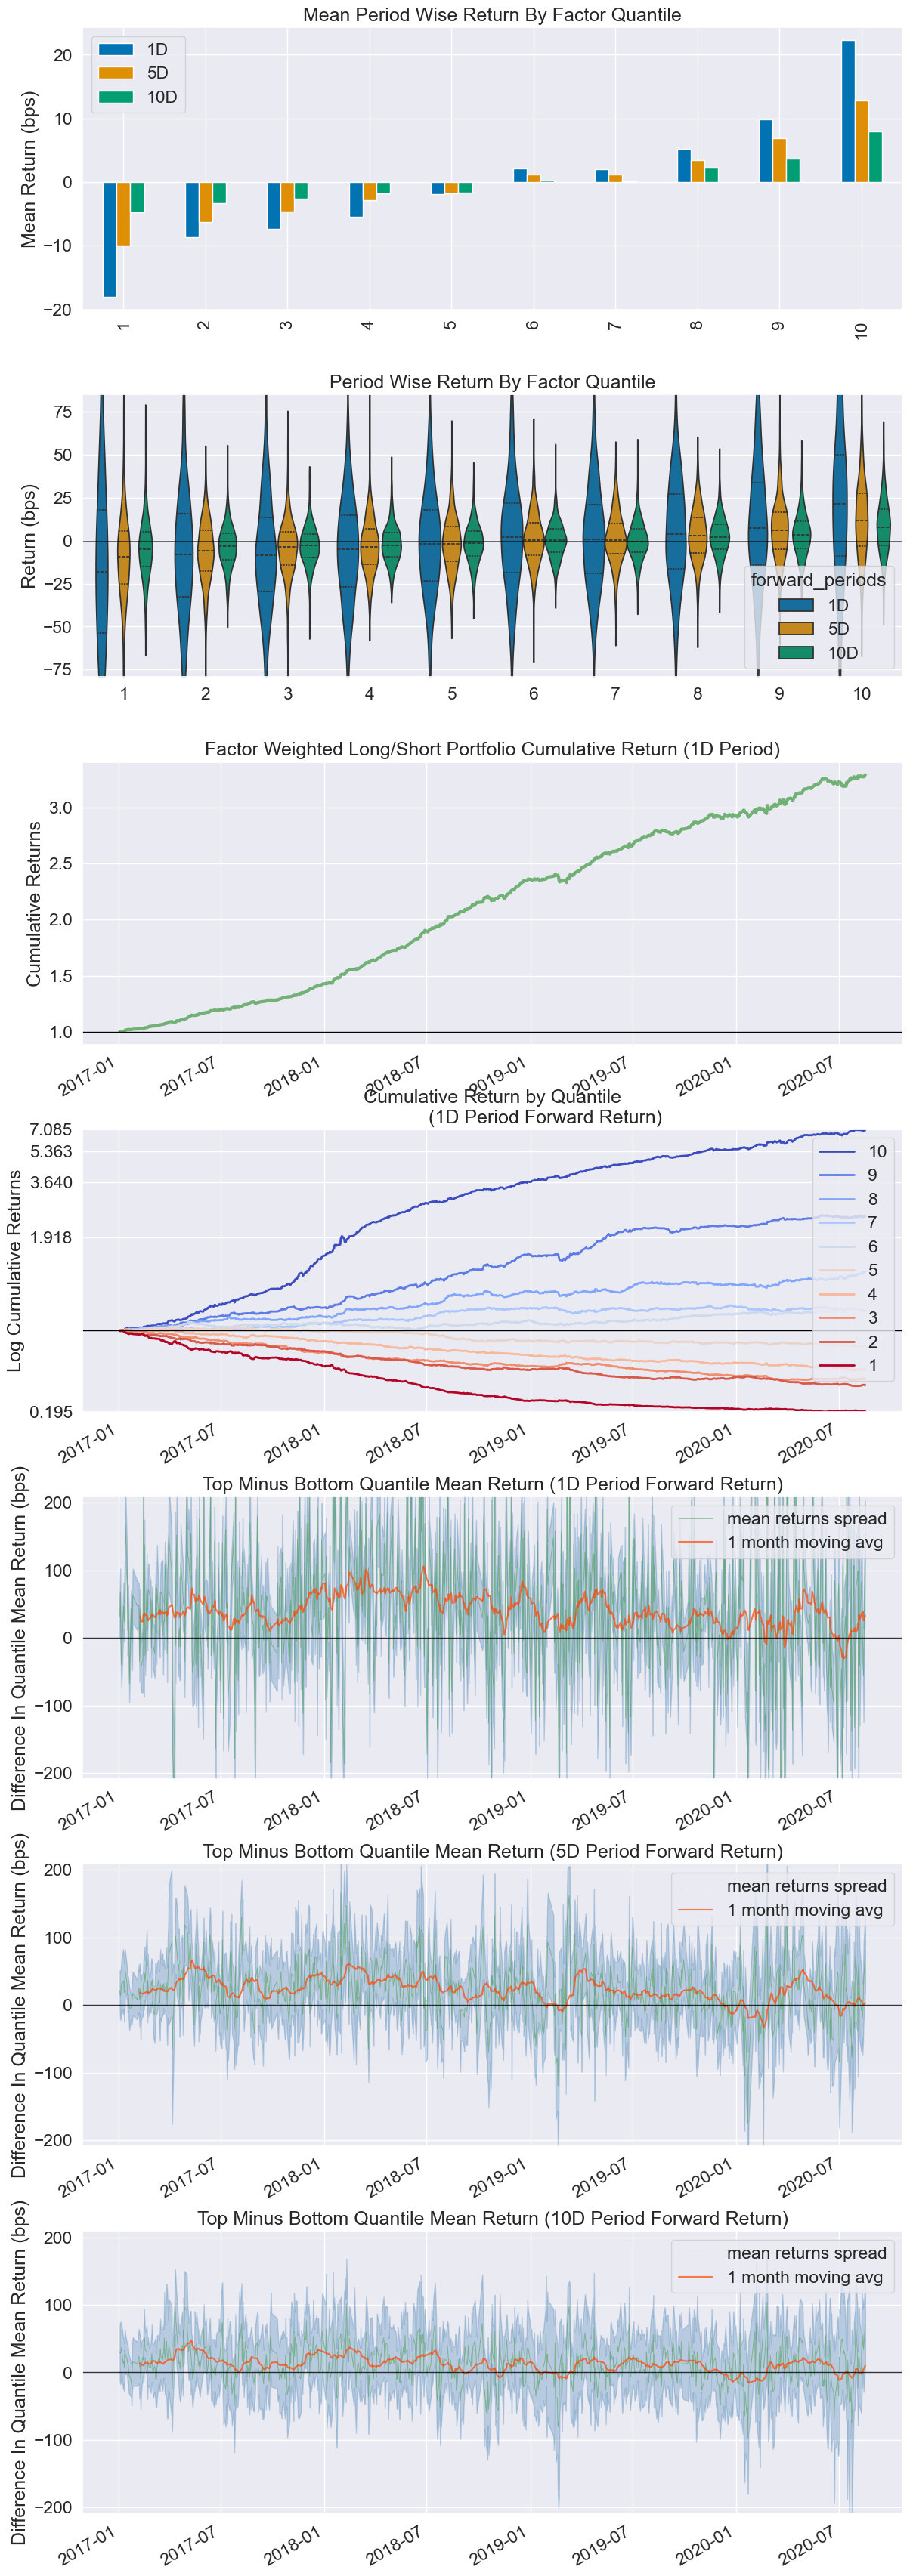

Information Analysis


,1D,5D,10D
IC Mean,0.075,0.089,0.070
IC Std.,0.123,0.120,0.116
Risk-Adjusted IC,0.611,0.739,0.599
t-stat(IC),18.149,21.948,17.791
p-value(IC),0.000,0.000,0.000
IC Skew,0.066,-0.019,-0.028
IC Kurtosis,0.544,0.170,0.136


D:\veighna_studio\Lib\site-packages\alphalens\performance.py:118: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  grouper.append(pd.Grouper(freq=by_time))


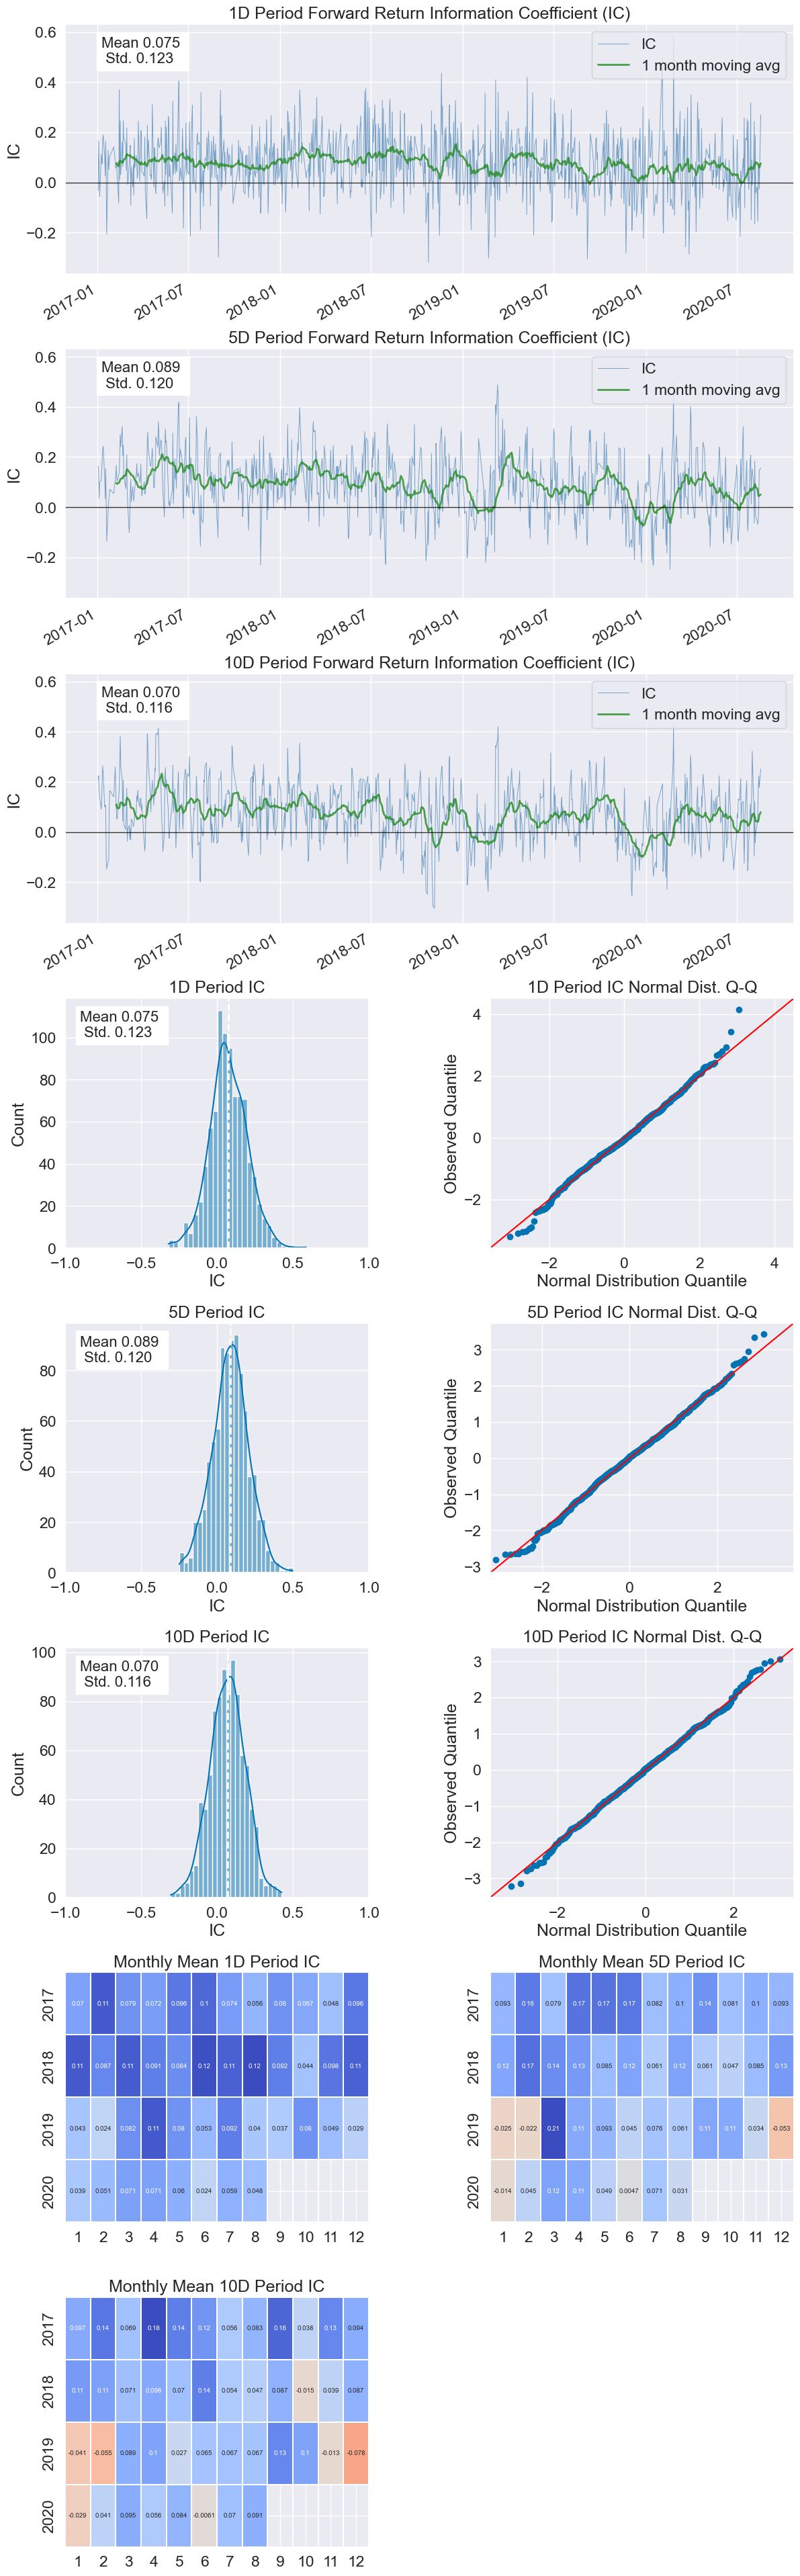

D:\veighna_studio\Lib\site-packages\alphalens\utils.py:928: UserWarning: Skipping return periods that aren't exact multiples of days.
  warnings.warn(


Turnover Analysis


,1D,5D,10D
Quantile 1 Mean Turnover,0.598,0.809,0.835
Quantile 2 Mean Turnover,0.783,0.871,0.879
Quantile 3 Mean Turnover,0.824,0.882,0.887
Quantile 4 Mean Turnover,0.840,0.885,0.891
Quantile 5 Mean Turnover,0.838,0.881,0.889
Quantile 6 Mean Turnover,0.844,0.882,0.889
Quantile 7 Mean Turnover,0.841,0.889,0.889
Quantile 8 Mean Turnover,0.826,0.880,0.884
Quantile 9 Mean Turnover,0.783,0.869,0.875
Quantile 10 Mean Turnover,0.593,0.848,0.861


,1D,5D,10D
Mean Factor Rank Autocorrelation,0.571,0.142,0.114


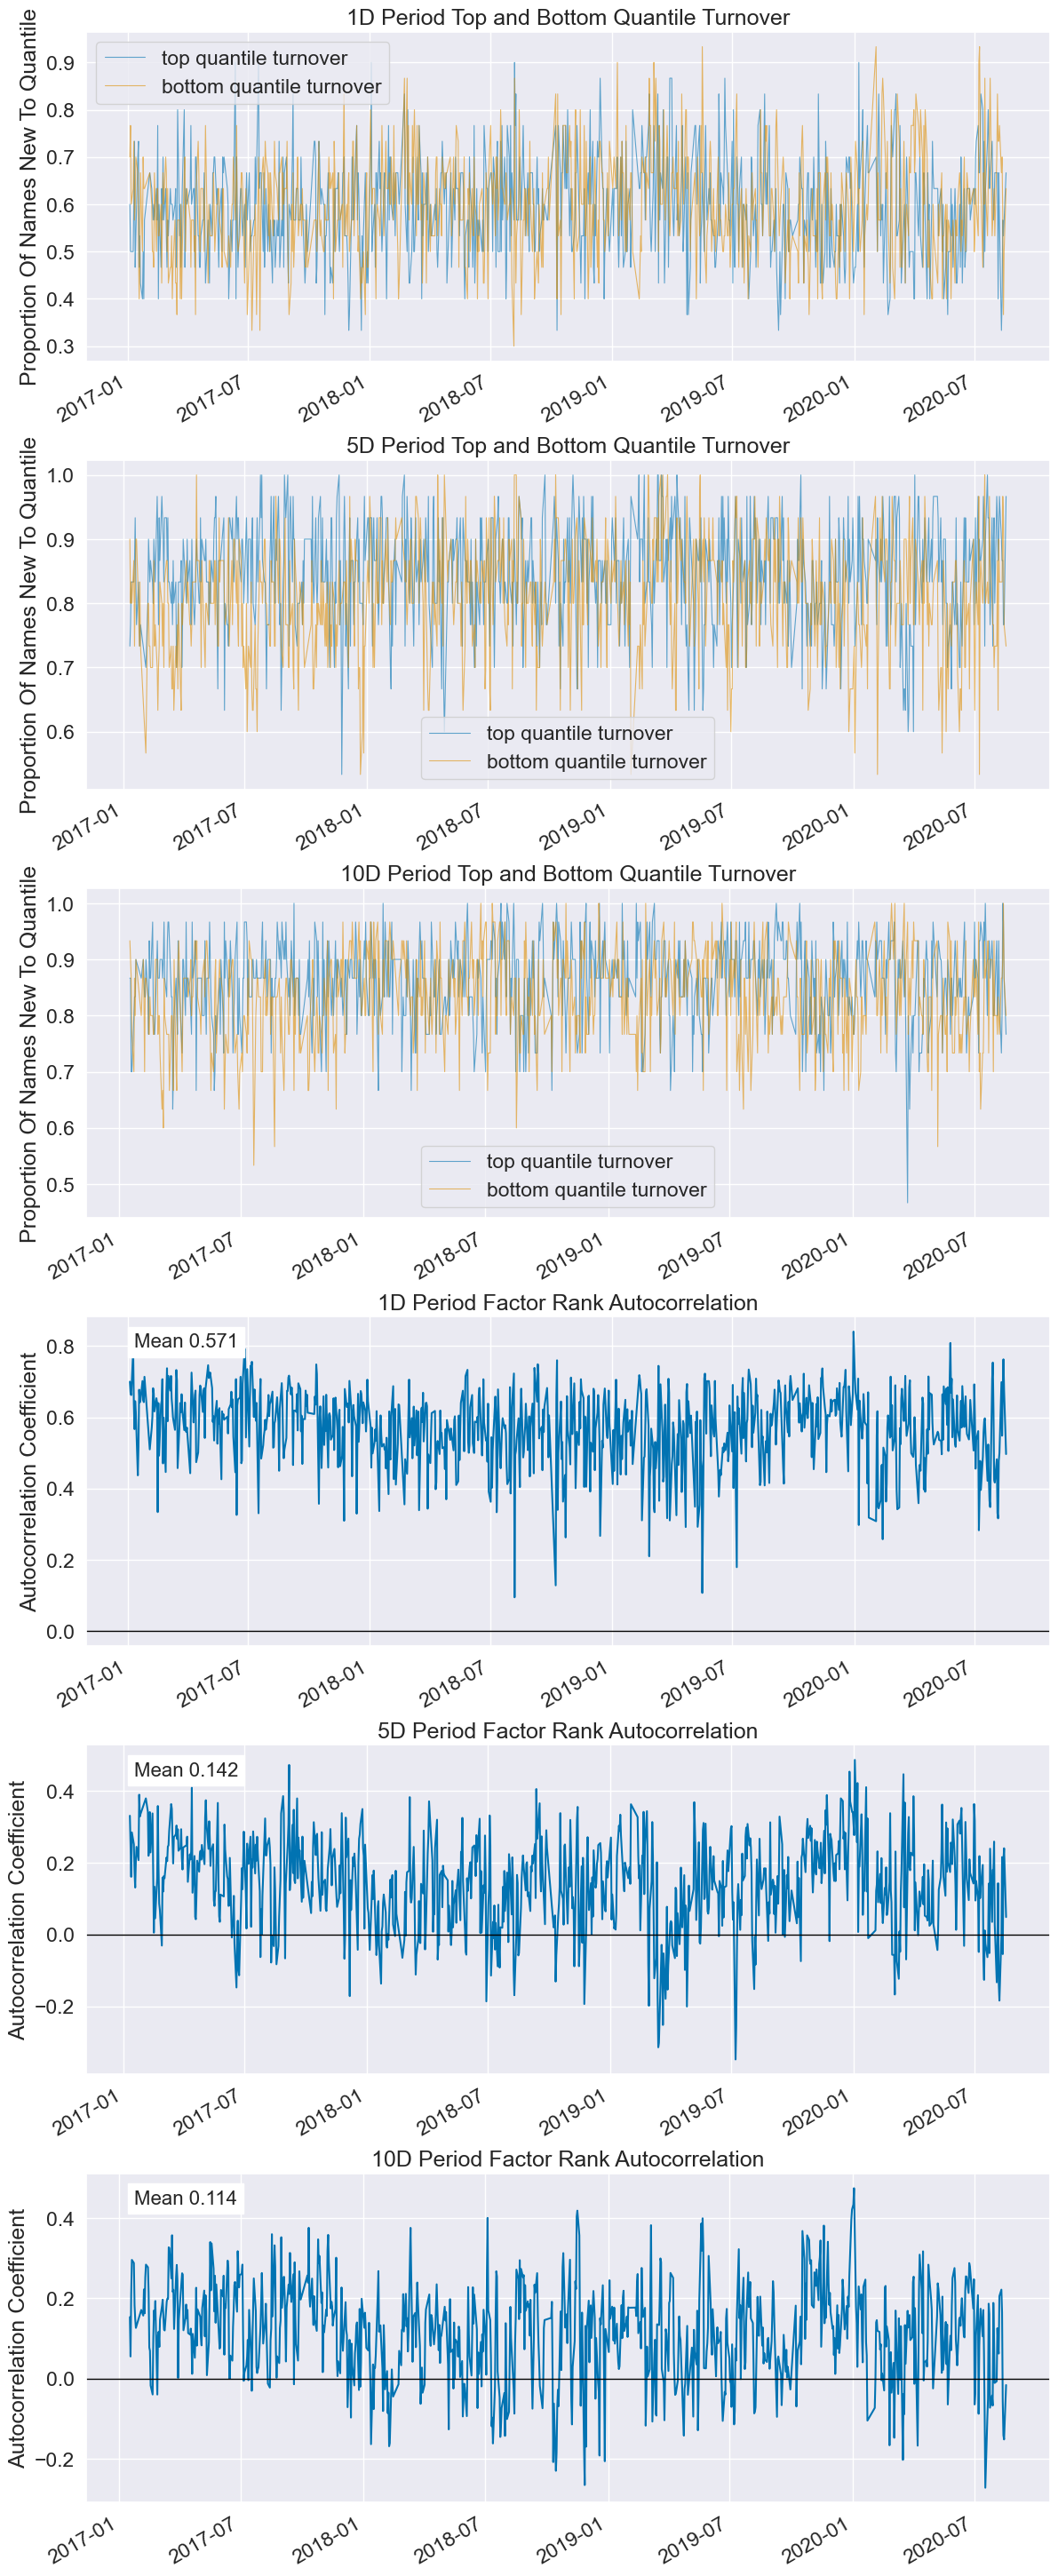

In [22]:
# 检查信号绩效
dataset.show_signal_performance(signal)

In [23]:
# 保存信号数据
lab.save_signal(name, signal)

# 策略回测

In [24]:
# 加载模块
import importlib
from datetime import datetime

from vnpy.alpha.strategy import BacktestingEngine

from vnpy.alpha.strategy.strategies.equity_demo_strategy import EquityDemoStrategy

In [25]:
# 从文件加载信号数据
signal = lab.load_signal(name)

In [26]:
# 创建回测引擎对象
engine = BacktestingEngine(lab)

# 设置回测参数
engine.set_parameters(
    vt_symbols=component_symbols,
    interval=Interval.DAILY,
    start=datetime(2017, 1, 1),
    end=datetime(2020, 8, 1),
    capital=100000000
)

# 添加策略实例
setting = {"top_k": 30, "n_drop": 3, "hold_thresh": 3}
engine.add_strategy(EquityDemoStrategy, setting, signal)

In [27]:
# 执行回测任务
engine.load_data()
engine.run_backtesting()
engine.calculate_result()
engine.calculate_statistics()
engine.show_chart()

2026-05-11 19:11:14 开始加载历史数据


100%|███████████████████████████████████████████████████████████████████████████████| 824/824 [00:07<00:00, 104.19it/s]

2026-05-11 19:11:22 部分合约历史数据为空：['603296.SSE', '601299.SSE', '688303.SSE', '688082.SSE', '300957.SZSE', '000024.SZSE', '600631.SSE', '001289.SZSE', '688065.SSE', '600087.SSE', '600905.SSE', '601059.SSE', '600941.SSE', '688187.SSE', '601728.SSE', '688041.SSE', '601995.SSE', '688223.SSE', '000527.SZSE', '300979.SZSE', '600591.SSE', '600938.SSE', '300919.SZSE', '600832.SSE', '600001.SSE', '601825.SSE', '601268.SSE', '300888.SZSE', '300999.SZSE', '600357.SSE', '301269.SZSE', '300866.SZSE', '000562.SZSE', '605499.SSE', '300896.SZSE', '605117.SSE', '688271.SSE', '600102.SSE', '600786.SSE', '601868.SSE']
2026-05-11 19:11:22 所有历史数据加载完成
2026-05-11 19:11:22 策略初始化完成
2026-05-11 19:11:22 开始回放历史数据


2026-05-11 19:11:28 历史数据回放结束
2026-05-11 19:11:28 开始计算逐日盯市盈亏
2026-05-11 19:11:29 逐日盯市盈亏计算完成
2026-05-11 19:11:29 开始计算策略统计指标
2026-05-11 19:11:29 ------------------------------
2026-05-11 19:11:29 首个交易日：  2017-01-03
2026-05-11 19:11:29 最后交易日：  2020-07-31
2026-05-11 19:11:29 总交易日：  871
2026-05-11 19:11:29 盈利交易日：  485
2026-05-11 19:11:29 亏损交易日：  385
2026-05-11 19:11:29 起始资金：  100,000,000.00
2026-05-11 19:11:29 结束资金：  324,565,329.91
2026-05-11 19:11:29 总收益率：  224.57%
2026-05-11 19:11:29 年化收益：  61.88%
2026-05-11 19:11:29 最大回撤:   -53,014,468.59
2026-05-11 19:11:29 百分比最大回撤: -21.98%
2026-05-11 19:11:29 最长回撤天数:   63
2026-05-11 19:11:29 总盈亏：  224,565,329.91
2026-05-11 19:11:29 总手续费：  22,472,273.96
2026-05-11 19:11:29 总成交金额：  29,988,321,513.38
2026-05-11 19:11:29 总成交笔数：  4710
2026-05-11 19:11:29 日均盈亏：  257,824.72
2026-05-11 19:11:29 日均手续费：  25,800.54
2026-05-11 19:11:29 日均成交金额：  34,429,760.64
2026-05-11 19:11:29 日均成交笔数：  5.407577497129736
2026-05-11 19:11:29 日均收益率：  0.14%
2026-05-11 19:11:29 收益标准差： 

D:\veighna_studio\Lib\site-packages\requests\__init__.py:113: RequestsDependencyWarning:

urllib3 (2.3.0) or chardet (7.4.3)/charset_normalizer (3.4.2) doesn't match a supported version!



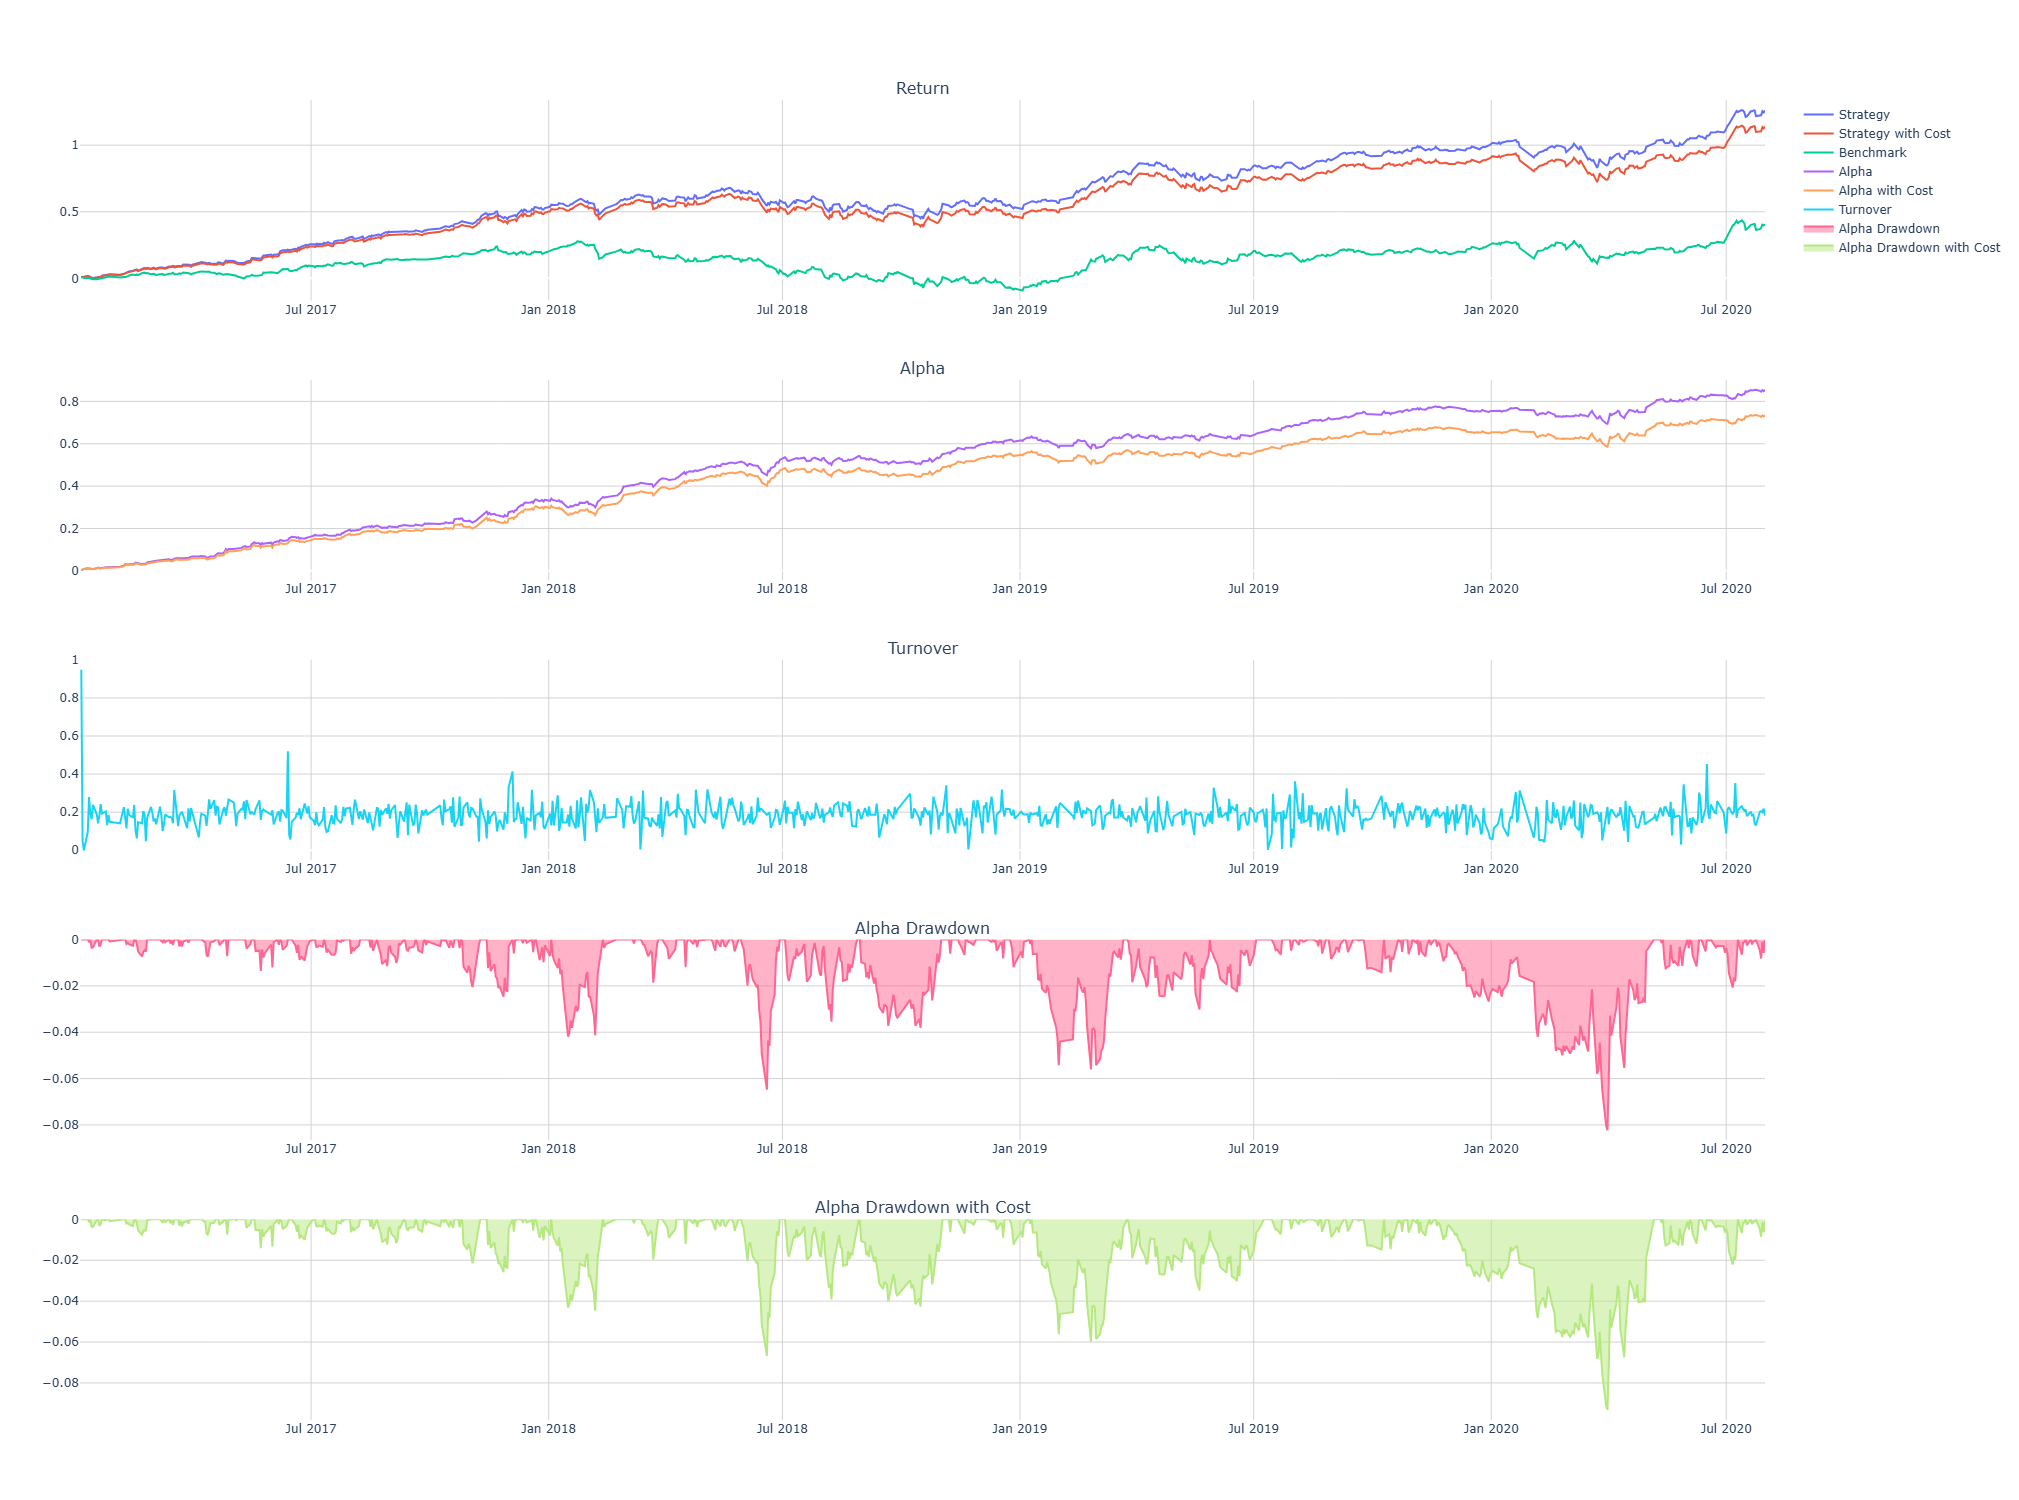

In [28]:
# 显示超额收益分析结果
engine.show_performance(benchmark_symbol=index_symbol)